In [1]:
!pip install connected-components-3d 
import cc3d

print('PIP OK !!!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 45.9 MB/s eta 0:00:00
PIP OK !!!


In [2]:
import sys
sys.path.append('/kaggle/input/hengck-demo-durface-detect')
from model import *

DEVICE='cpu'
KAGGLE_DIR = '/kaggle/input/vesuvius-challenge-surface-detection'
print('IMPORT OK !!!')

IMPORT OK !!!


In [3]:
# a good 3d unet trained with 500+ epochs with many augmentations
checkpoint='/kaggle/input/hengck-demo-durface-detect/00013040.pth'
net = Net()
f = torch.load(checkpoint, map_location=lambda storage, loc: storage, weights_only=False)
state_dict = f['state_dict']
print(net.load_state_dict(state_dict, strict=False))  


# if you want to play with this model, i include the data split here
def split_data(fold=0):
    df = pd.read_csv(KAGGLE_DIR + '/train.csv')
    df['fold'] = np.arange(len(df)) % 5
    train_df = df[df['fold'] != fold].reset_index(drop=True)
    valid_df = df[df['fold'] == fold].reset_index(drop=True)
    return train_df, valid_df
    
#load dummy data (validation sample not used in training)
id = 1354910392 
tif_file = f'/kaggle/input/hengck-demo-durface-detect/1354910392.image.npy'
mask_file = f'/kaggle/input/hengck-demo-durface-detect/1354910392.thin-truth.npy'
image = np.load(tif_file)
scroll = np.load(mask_file)

ignore = scroll == 2
scroll[ignore] = 0 #mask out for simplicity in discussion

batch={
    'image': torch.from_numpy(image).unsqueeze(0).unsqueeze(0),
    'scroll': torch.from_numpy(scroll).unsqueeze(0),
}

net.to(DEVICE)
net.eval()
with torch.no_grad():
    #with torch.amp.autocast('cuda', dtype=torch.bfloat16):
        output = net(batch)
        loss = output['pixel_loss']
print('loss',loss.item())
prob = output['scroll'][0,1].float().detach().numpy()
#np.save(f'{id}.prob.npy', prob)

'''
loss 0.154550701379776
'''

<All keys matched successfully>
loss 0.154550701379776


'\nloss 0.154550701379776\n'

(128, 128, 128) (128, 128, 128) (128, 128, 128)


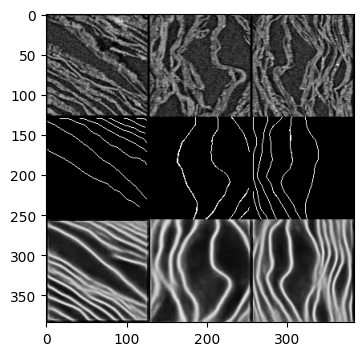

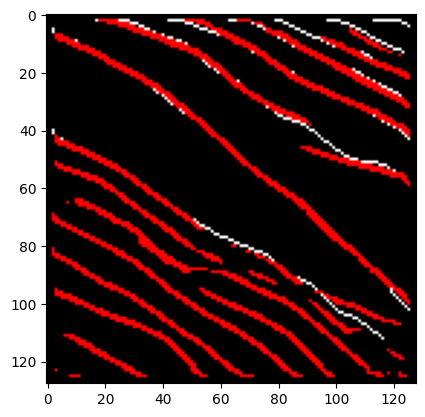

In [4]:
#let's analyse results
import matplotlib.pyplot as plt
import matplotlib


#prob = np.load(f'{id}.prob.npy')
print(prob.shape, image.shape, scroll.shape)
 
m = image
m3 = np.hstack([m[64], m[:, 64], m[:, :, 64]])
p = prob
p3 = np.hstack([p[64], p[:, 64], p[:, :, 64]])
y = scroll
y3 = np.hstack([y[64], y[:, 64], y[:, :, 64]])

overlay =np.dstack((y[64], y[64], y[64]))
overlay[p[64]>0.25]=[1,0,0]
overlay = (overlay*255).astype(np.uint8)

plt.figure(figsize=(4, 4)) 
plt.imshow(np.vstack([m3/255,y3,p3**0.25]), cmap='gray')
plt.show()

plt.imshow(overlay)
plt.show()

In [5]:
#lets show in 3d

predict = (prob>0.25).astype(np.uint8)
predict[ignore] = 0 #ignore for simplicity

cc = cc3d.connected_components(predict) # 26-connected
cc = cc3d.dust(cc,threshold=50)
cc = cc3d.connected_components(cc>0)
print(cc.max())

#for 3d visualisation function, 
# refer to:refer to: https://www.kaggle.com/code/hengck23/demo-for-line-tracing-for-filling-holes

#show_in_3d(cc)

10



expected results
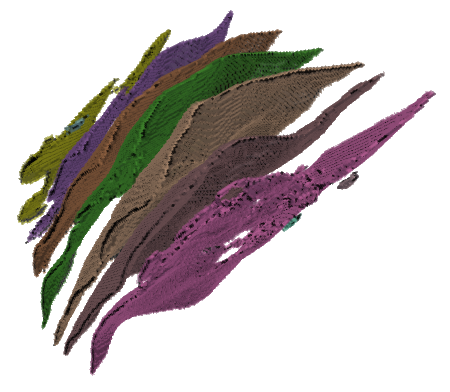

In [6]:
# show one by one
#for n in range(1,cc.max()+1):
#    print(n) #1
#    show_in_3d(cc==n)

expected results
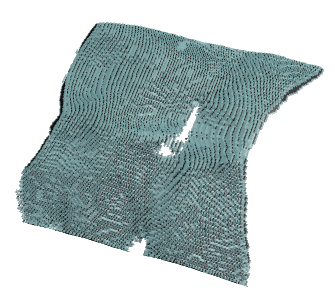
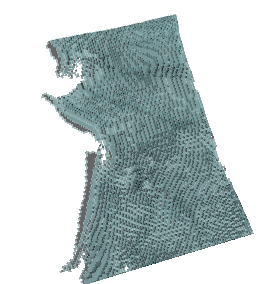
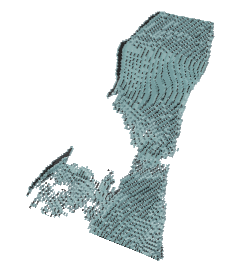
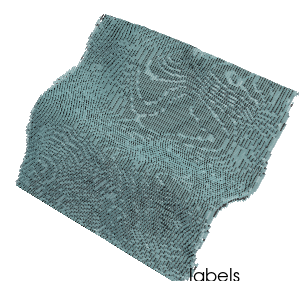
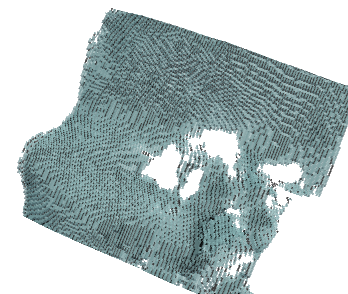